In [ ]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
df = pd.read_csv("/bin/content/fighter_aircraft_dataset_v10 (1).csv")
df

,Aircraft,Manufacturer,Country,Generation,Role,First_Flight,In_Service,Max_Speed_kmh,Supercruise_kmh,Service_Ceiling_m,...,EW_Score,Combat_Kills,Combat_Losses_AirToAir,Combat_Record_Status,Kill_Loss_Ratio,Combat_Kills_A2A,Combat_Losses_A2A,Combat_Status,Kill_Ratio,Combat_Sorties_Estimated
0,F-22A Raptor,Lockheed Martin,USA,5,Air Superiority,1997,2005,2130,1810,15000,...,0.95,0.0,0,Limited,0.000000,0.0,0,Limited,NaN,2500
1,F-35A Lightning II,Lockheed Martin,USA,5,Multirole,2006,2016,1960,0,15240,...,1.00,0.0,0,Limited,0.000000,0.0,0,Limited,1.000000,8000
2,Su-57 Felon,Sukhoi,Russia,5,Multirole,2010,2020,2135,1400,20000,...,0.75,1.0,0,NaN,0.000000,0.0,0,Limited,NaN,500
3,F-15C Eagle,Boeing,USA,4,Air Superiority,1972,1976,2655,0,20000,...,0.35,104.0,0,Extensive,104.000000,104.0,0,Extensive,104.000000,50000
4,F-15EX Eagle II,Boeing,USA,4.5,Multirole,2021,2024,2655,0,20000,...,0.70,0.0,0,NaN,0.000000,0.0,0,NaN,NaN,0
5,F-16C Fighting Falcon,Lockheed Martin,USA,4,Multirole,1974,1978,2120,0,15240,...,0.40,76.0,5,Extensive,76.000000,76.0,1,Extensive,38.000000,200000
6,F/A-18E Super Hornet,Boeing,USA,4.5,Multirole,1995,2001,1915,0,15240,...,0.65,1.0,0,Limited,1.000000,1.0,0,Extensive,1.000000,30000
7,Su-35S Flanker-E,Sukhoi,Russia,4++,Air Superiority,2008,2014,2500,0,18000,...,0.50,0.0,1,Limited,0.000000,0.0,0,Limited,NaN,3000
8,Su-27 Flanker,Sukhoi,Russia,4,Air Superiority,1977,1985,2500,0,18500,...,0.20,6.0,10,Limited,0.500000,6.0,10,Extensive,1.500000,15000
9,MiG-29 Fulcrum,Mikoyan,Russia,4,Air Superiority,1977,1983,2400,0,18000,...,0.15,5.0,27,Extensive,0.181818,4.0,24,Extensive,0.166667,20000


In [ ]:
#for first 5 rows
df.head()
#for last 5 rows
df.tail()
# to show how many rows and columns present in a dataset
df.shape
#To show names of the column in dataset
df.columns
for col in df.columns:
  print(col)
print(df.columns.tolist())

Aircraft
Manufacturer
Country
Generation
Role
First_Flight
In_Service
Max_Speed_kmh
Supercruise_kmh
Service_Ceiling_m
Combat_Radius_km
Ferry_Range_km
Empty_Weight_kg
MTOW_kg
Hardpoints
Max_Weapon_Load_kg
Radar_Type
Radar_Model
RCS_m2
Engine_Count
Engine_Model
Thrust_per_Engine_kN
Supercruise_Capable
Thrust_Vectoring
Internal_Weapons_Bay
Units_Produced
Unit_Cost_M_USD
Status
Internal_Fuel_kg
Fuel_Consumption_Cruise_kg_h
Number_of_Operators
Cruise_Speed_kmh
Cost_per_Flight_Hour_USD
Radar_Score
Missile_Score
EW_Score
Combat_Kills
Combat_Losses_AirToAir
Combat_Record_Status
Kill_Loss_Ratio
Combat_Kills_A2A
Combat_Losses_A2A
Combat_Status
Kill_Ratio
Combat_Sorties_Estimated
['Aircraft', 'Manufacturer', 'Country', 'Generation', 'Role', 'First_Flight', 'In_Service', 'Max_Speed_kmh', 'Supercruise_kmh', 'Service_Ceiling_m', 'Combat_Radius_km', 'Ferry_Range_km', 'Empty_Weight_kg', 'MTOW_kg', 'Hardpoints', 'Max_Weapon_Load_kg', 'Radar_Type', 'Radar_Model', 'RCS_m2', 'Engine_Count', 'Engine_Model'

In [ ]:
df.dtypes

In [ ]:
df.describe()
# Data Cleaning
df.isnull().sum()
df.isnull().sum().sum()
df.drop_duplicates(inplace=True)

#Check duplicates
df.duplicated().sum()

#Unique values in categorical columns
print(df['Country'].unique())
print(df['Generation'].unique())
print(df['Role'].unique())

# Fill missing numerical values
df.fillna(df.select_dtypes(include='number').mean(), inplace=True)

# Fill missing categorical values
df['Combat_Record_Status'].fillna('Unknown', inplace=True)
df['Combat_Status'].fillna('Unknown', inplace=True)

#Remove duplicates
df.drop_duplicates(inplace=True)

#Final verification
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nTotal Missing Values:",
      df.isnull().sum().sum())

print("\nDuplicate Records:",
      df.duplicated().sum())

['USA' 'Russia' 'China' 'China/Pakistan' 'Europe' 'France' 'Sweden'
 'India' 'South Korea' 'Russia/India' 'Japan' 'USA/Saudi Arabia' 'UK']
['5' '4' '4.5' '4++' '4+' '3' '2']
['Air Superiority' 'Multirole' 'Interceptor']

Missing Values After Cleaning:
Aircraft                        0
Manufacturer                    0
Country                         0
Generation                      0
Role                            0
First_Flight                    0
In_Service                      0
Max_Speed_kmh                   0
Supercruise_kmh                 0
Service_Ceiling_m               0
Combat_Radius_km                0
Ferry_Range_km                  0
Empty_Weight_kg                 0
MTOW_kg                         0
Hardpoints                      0
Max_Weapon_Load_kg              0
Radar_Type                      0
Radar_Model                     0
RCS_m2                          0
Engine_Count                    0
Engine_Model                    0
Thrust_per_Engine_kN            0


/tmp/ipykernel_11855/4189567966.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Combat_Record_Status'].fillna('Unknown', inplace=True)
/tmp/ipykernel_11855/4189567966.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [ ]:
# Data Filtering

#aircraft from USA
df[df['Country']=='USA']
df['Generation'].unique()

#fifth generation aircraft
df[df['Generation']=='5']

#aircraft with thrust_vectoring
df[df['Thrust_Vectoring']=='Yes']

#supercruise capable aircrafts
df[df['Supercruise_Capable']=='Yes']

#aircraft speed above 2000
df[df['Max_Speed_kmh']>2000]

,Aircraft,Manufacturer,Country,Generation,Role,First_Flight,In_Service,Max_Speed_kmh,Supercruise_kmh,Service_Ceiling_m,...,EW_Score,Combat_Kills,Combat_Losses_AirToAir,Combat_Record_Status,Kill_Loss_Ratio,Combat_Kills_A2A,Combat_Losses_A2A,Combat_Status,Kill_Ratio,Combat_Sorties_Estimated
0,F-22A Raptor,Lockheed Martin,USA,5,Air Superiority,1997,2005,2130,1810,15000,...,0.95,0.0,0,Limited,0.000000,0.0,0,Limited,8.378841,2500
2,Su-57 Felon,Sukhoi,Russia,5,Multirole,2010,2020,2135,1400,20000,...,0.75,1.0,0,Unknown,0.000000,0.0,0,Limited,8.378841,500
3,F-15C Eagle,Boeing,USA,4,Air Superiority,1972,1976,2655,0,20000,...,0.35,104.0,0,Extensive,104.000000,104.0,0,Extensive,104.000000,50000
4,F-15EX Eagle II,Boeing,USA,4.5,Multirole,2021,2024,2655,0,20000,...,0.70,0.0,0,Unknown,0.000000,0.0,0,Unknown,8.378841,0
5,F-16C Fighting Falcon,Lockheed Martin,USA,4,Multirole,1974,1978,2120,0,15240,...,0.40,76.0,5,Extensive,76.000000,76.0,1,Extensive,38.000000,200000
7,Su-35S Flanker-E,Sukhoi,Russia,4++,Air Superiority,2008,2014,2500,0,18000,...,0.50,0.0,1,Limited,0.000000,0.0,0,Limited,8.378841,3000
8,Su-27 Flanker,Sukhoi,Russia,4,Air Superiority,1977,1985,2500,0,18500,...,0.20,6.0,10,Limited,0.500000,6.0,10,Extensive,1.500000,15000
9,MiG-29 Fulcrum,Mikoyan,Russia,4,Air Superiority,1977,1983,2400,0,18000,...,0.15,5.0,27,Extensive,0.181818,4.0,24,Extensive,0.166667,20000
10,MiG-31 Foxhound,Mikoyan,Russia,4,Interceptor,1975,1981,3000,0,20600,...,0.45,0.0,0,Unknown,1.000000,1.0,0,Limited,8.378841,2000
11,J-20 Mighty Dragon,Chengdu,China,5,Air Superiority,2011,2017,2100,0,20000,...,0.65,0.0,0,Unknown,0.000000,0.0,0,Unknown,8.378841,0


In [ ]:
#Grouping

#Average speed by country
df.groupby('Country')['Max_Speed_kmh'].mean()

#average combat radius by generation
df.groupby('Generation')['Combat_Radius_km'].mean()

#average unit cost by country
df.groupby('Country')['Unit_Cost_M_USD'].mean()


,Unit_Cost_M_USD
Country,
China,61.000000
China/Pakistan,32.000000
Europe,74.000000
France,46.500000
India,42.000000
Japan,100.000000
Russia,28.454545
Russia/India,60.000000
South Korea,72.000000


In [ ]:
#Sorting

df.sort_values('Max_Speed_kmh',ascending=False)
df.sort_values('Unit_Cost_M_USD',ascending=False)
df.sort_values('Combat_Radius_km',ascending=False)

,Aircraft,Manufacturer,Country,Generation,Role,First_Flight,In_Service,Max_Speed_kmh,Supercruise_kmh,Service_Ceiling_m,...,EW_Score,Combat_Kills,Combat_Losses_AirToAir,Combat_Record_Status,Kill_Loss_Ratio,Combat_Kills_A2A,Combat_Losses_A2A,Combat_Status,Kill_Ratio,Combat_Sorties_Estimated
43,F-106A Delta Dart,Convair,USA,3,Interceptor,1956,1959,2454,0,17000,...,0.15,0.0,0,Unknown,5.201374,0.0,0,Unknown,8.378841,0
3,F-15C Eagle,Boeing,USA,4,Air Superiority,1972,1976,2655,0,20000,...,0.35,104.0,0,Extensive,104.000000,104.0,0,Extensive,104.000000,50000
33,F-15SA,Boeing,USA/Saudi Arabia,4.5,Multirole,2013,2017,2655,0,20000,...,0.60,0.0,0,Unknown,0.000000,0.0,0,Limited,8.378841,3000
4,F-15EX Eagle II,Boeing,USA,4.5,Multirole,2021,2024,2655,0,20000,...,0.70,0.0,0,Unknown,0.000000,0.0,0,Unknown,8.378841,0
20,Panavia Tornado ADV,Panavia,Europe,4,Interceptor,1979,1986,2340,0,15240,...,0.25,0.0,0,Limited,0.000000,0.0,0,Limited,8.378841,15000
31,Rafale F4,Dassault,France,4.5,Multirole,2023,2024,1912,0,15835,...,0.80,0.0,0,Unknown,0.000000,0.0,0,Unknown,8.378841,0
15,Dassault Rafale,Dassault,France,4.5,Multirole,1986,2001,1912,0,15835,...,0.75,0.0,1,Limited,0.000000,0.0,0,Extensive,0.000000,8000
7,Su-35S Flanker-E,Sukhoi,Russia,4++,Air Superiority,2008,2014,2500,0,18000,...,0.50,0.0,1,Limited,0.000000,0.0,0,Limited,8.378841,3000
22,Mirage 2000-5,Dassault,France,4,Multirole,1978,1988,2340,0,17060,...,0.35,3.0,1,Limited,2.000000,2.0,0,Extensive,3.000000,10000
23,Su-30MKI Flanker-H,Sukhoi,Russia/India,4.5,Multirole,1996,2002,2120,0,17300,...,0.40,0.0,1,Limited,0.000000,0.0,0,Limited,0.000000,3000


In [ ]:
#Aggregations


#Mean

df[['Max_Speed_kmh','Combat_Radius_km',
    'Unit_Cost_M_USD']].mean()
    #maximum
df[['Max_Speed_kmh','Combat_Radius_km',
    'Unit_Cost_M_USD']].max()
    #minimum
df[['Max_Speed_kmh','Combat_Radius_km',
    'Unit_Cost_M_USD']].min()
    #mode
df.mode()

#variance

df[['Max_Speed_kmh',
    'Combat_Radius_km',
    'Unit_Cost_M_USD']].var()

In [ ]:
#Queries

#number of aircraft
df['Aircraft'].count()

#number of countries
df['Country'].nunique()

#Fastest aircraft
df.loc[df['Max_Speed_kmh'].idxmax()]

#Slowest aircraft
df.loc[df['Max_Speed_kmh'].idxmin()]

#Most expensive aircraft
df.loc[df['Unit_Cost_M_USD'].idxmax()]

#Cheapest Aircraft
df.loc[df['Unit_Cost_M_USD'].idxmin()]

#Highest combat radius
df.loc[df['Combat_Radius_km'].idxmax()]

#Highest service ceiling
df.loc[df['Service_Ceiling_m'].idxmax()]

#Aircraft with maximum thrust
df.loc[df['Thrust_per_Engine_kN'].idxmax()]

#Top 5 fastest aircraft
df.nlargest(5,'Max_Speed_kmh')

,Aircraft,Manufacturer,Country,Generation,Role,First_Flight,In_Service,Max_Speed_kmh,Supercruise_kmh,Service_Ceiling_m,...,EW_Score,Combat_Kills,Combat_Losses_AirToAir,Combat_Record_Status,Kill_Loss_Ratio,Combat_Kills_A2A,Combat_Losses_A2A,Combat_Status,Kill_Ratio,Combat_Sorties_Estimated
10,MiG-31 Foxhound,Mikoyan,Russia,4,Interceptor,1975,1981,3000,0,20600,...,0.45,0.0,0,NaN,1.00,1.0,0,Limited,NaN,2000
39,MiG-25PD Foxbat,Mikoyan,Russia,3,Interceptor,1969,1979,3000,0,20700,...,0.20,3.0,7,Limited,0.43,3.0,7,Limited,0.43,5000
3,F-15C Eagle,Boeing,USA,4,Air Superiority,1972,1976,2655,0,20000,...,0.35,104.0,0,Extensive,104.00,104.0,0,Extensive,104.00,50000
4,F-15EX Eagle II,Boeing,USA,4.5,Multirole,2021,2024,2655,0,20000,...,0.70,0.0,0,NaN,0.00,0.0,0,NaN,NaN,0
19,F-15E Strike Eagle,Boeing,USA,4,Multirole,1986,1989,2655,0,18200,...,0.35,2.0,2,Extensive,2.00,2.0,0,Extensive,2.00,60000


In [ ]:
#Top 5 expensive aircraft
df.nlargest(5,'Unit_Cost_M_USD')

#Country-wise aircraft count
df['Country'].value_counts()

#Average speed by generation
df.groupby('Generation')['Max_Speed_kmh'].mean()

#Average cost by country
df.groupby('Country')['Unit_Cost_M_USD'].mean()

#Aircraft with radar score above 0.5
print(df['Radar_Score'])
df[df['Radar_Score']>0.5]

#Aircraft with missile score above 0.75
print(df['Missile_Score'])
df[df['Missile_Score']>0.75]

#Aircraft with combat kills greater than 50
df[df['Combat_Kills']>50]

#Aircraft having internal weapons bay
df[df['Internal_Weapons_Bay']=='Yes']

#Average flight hour cost
df['Cost_per_Flight_Hour_USD'].mean()

#Aircraft with highest kill ratio
df.loc[df['Kill_Ratio'].idxmax()]


0     0.90
1     0.95
2     0.95
3     0.30
4     0.85
5     0.25
6     0.80
7     0.50
8     0.20
9     0.15
10    0.85
11    0.70
12    0.60
13    0.60
14    0.70
15    0.70
16    0.65
17    0.60
18    0.80
19    0.85
20    0.20
21    0.30
22    0.25
23    0.40
24    0.65
25    0.25
26    0.65
27    0.55
28    0.70
29    0.82
30    0.48
31    0.75
32    0.58
33    0.80
34    0.15
35    0.45
36    0.40
37    0.20
38    0.25
39    0.25
40    0.05
41    0.20
42    0.15
43    0.30
44    0.15
45    0.05
46    0.20
47    0.90
Name: Radar_Score, dtype: float64
0     0.90
1     0.90
2     0.90
3     0.75
4     0.90
5     0.75
6     0.90
7     0.90
8     0.60
9     0.60
10    0.87
11    0.85
12    0.85
13    0.85
14    0.90
15    0.90
16    0.90
17    0.55
18    0.75
19    0.90
20    0.70
21    0.50
22    0.60
23    0.60
24    0.75
25    0.75
26    0.85
27    0.90
28    0.90
29    0.90
30    0.90
31    0.90
32    0.85
33    0.90
34    0.45
35    0.75
36    0.70
37    0.50
38    0.50
39    0.4

,3
Aircraft,F-15C Eagle
Manufacturer,Boeing
Country,USA
Generation,4
Role,Air Superiority
First_Flight,1972
In_Service,1976
Max_Speed_kmh,2655
Supercruise_kmh,0
Service_Ceiling_m,20000


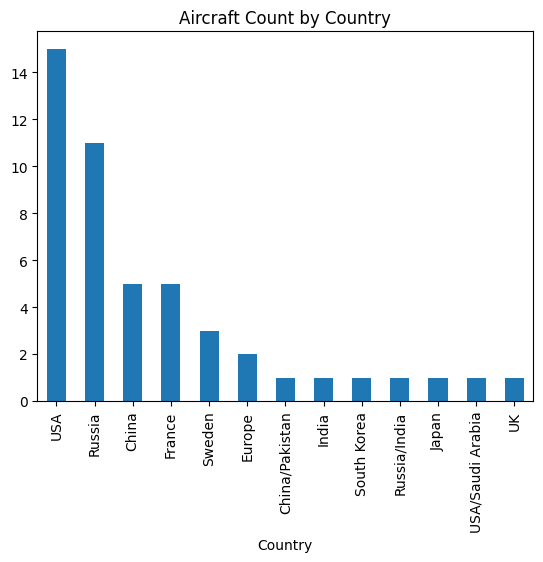

In [ ]:
#Data Visualization


#Bar Graph

import matplotlib.pyplot as plt

df['Country'].value_counts().plot(kind='bar')
plt.title("Aircraft Count by Country")
plt.show()

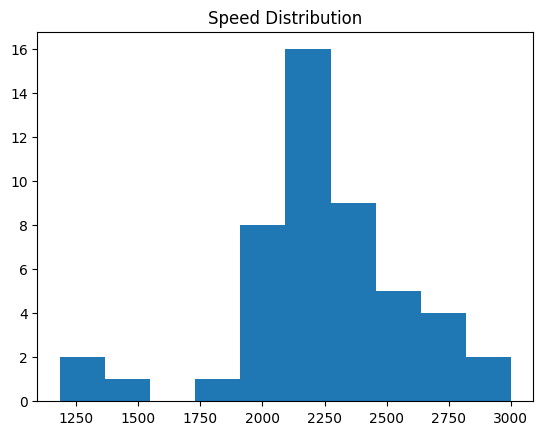

In [ ]:
#Histogram

plt.hist(df['Max_Speed_kmh'],bins=10)
plt.title("Speed Distribution")
plt.show()

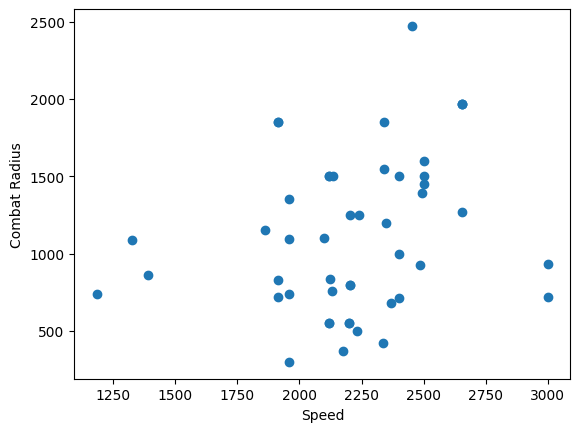

In [ ]:
#Scatter plot

plt.scatter(df['Max_Speed_kmh'],
            df['Combat_Radius_km'])
plt.xlabel("Speed")
plt.ylabel("Combat Radius")
plt.show()


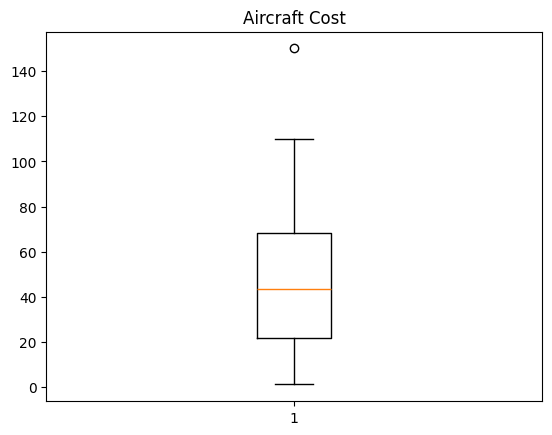

In [ ]:
#Box plot

plt.boxplot(df['Unit_Cost_M_USD'])
plt.title("Aircraft Cost")
plt.show()


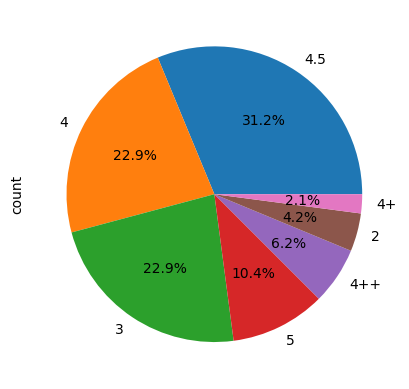

In [ ]:
#Pie plot

df['Generation'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.show()

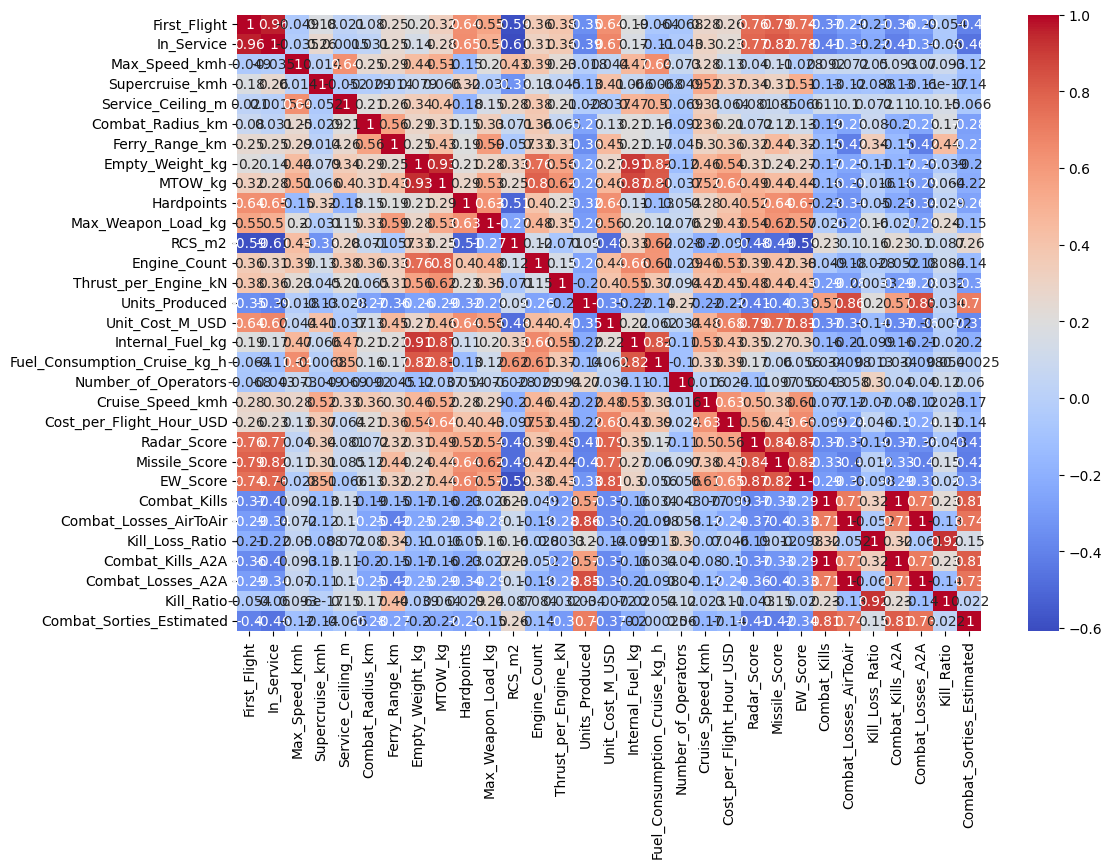

In [ ]:
#Heat map

import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
def max_subarray(arr):
    current_sum = arr[0]
    max_sum = arr[0]

    for i in range(1, len(arr)):
        current_sum = max(arr[i], current_sum + arr[i])
        max_sum = max(max_sum, current_sum)

    return max_sum


arr = [-2, 1, -3, 4, -1, 2, 1, -5, 4]

print("Maximum Subarray Sum:", max_subarray(arr))

Maximum Subarray Sum: 6
